In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [5]:
# Load cleaned dataset
data_path = "../data/processed/weather_cleaned_with_seasons.csv"
df = pd.read_csv(data_path)
df.head()

,timezone,country,location_name,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,...,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,season
0,NaN,Afghanistan,Kabul,34.52,69.18,1715849100,26.6,79.8,Partly Cloudy,8.3,...,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024,5,Spring
1,NaN,Albania,Tirana,41.33,19.82,1715849100,19.0,66.2,Partly cloudy,6.9,...,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55,2024,5,Spring
2,NaN,Algeria,Algiers,36.76,3.05,1715849100,23.0,73.4,Sunny,9.4,...,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55,2024,5,Spring
3,NaN,Andorra,Andorra La Vella,42.50,1.52,1715849100,6.3,43.3,Light drizzle,7.4,...,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55,2024,5,Spring
4,NaN,Angola,Luanda,-8.84,13.23,1715849100,26.0,78.8,Partly cloudy,8.1,...,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55,2024,5,Spring


In [6]:
# Summary statistics
df[["temperature_celsius", "humidity", "precip_mm", "wind_kph"]].describe()

,temperature_celsius,humidity,precip_mm,wind_kph
count,125501.000000,125501.000000,125501.000000,125501.000000
mean,21.573732,66.168612,0.136729,12.984579
std,9.611703,24.022895,0.570692,11.841975
min,-29.800000,2.000000,0.000000,3.600000
25%,16.300000,50.000000,0.000000,6.100000
50%,24.100000,71.000000,0.000000,11.200000
75%,28.100000,85.000000,0.030000,17.600000
max,49.200000,100.000000,42.240000,2963.200000


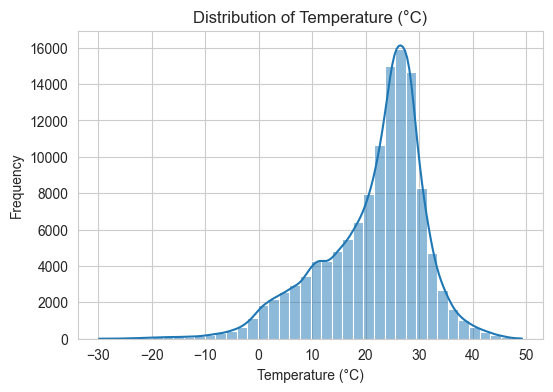

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["temperature_celsius"], bins=40, kde=True)
plt.title("Distribution of Temperature (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

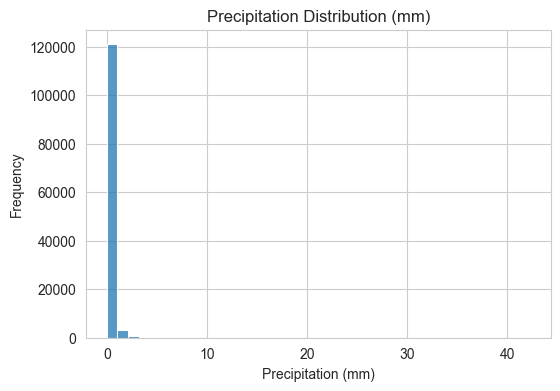

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df["precip_mm"], bins=40)
plt.title("Precipitation Distribution (mm)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.show()

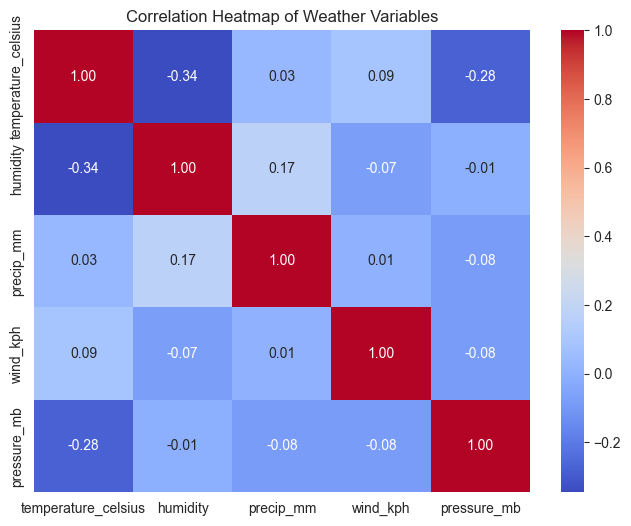

In [9]:
corr = df[
    ["temperature_celsius", "humidity", "precip_mm", "wind_kph", "pressure_mb"]
].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Weather Variables")
plt.show()

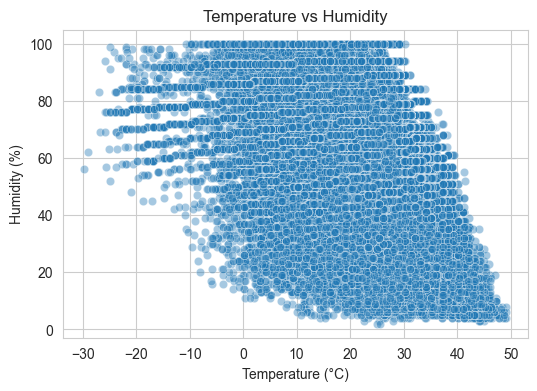

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=df["temperature_celsius"],
    y=df["humidity"],
    alpha=0.4
)
plt.title("Temperature vs Humidity")
plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.show()

In [11]:
seasonal_avg = (
    df.groupby("season")[["temperature_celsius", "precip_mm"]]
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Autumn"])
)

seasonal_avg

,temperature_celsius,precip_mm
season,,
Winter,16.607986,0.114478
Spring,22.309705,0.139798
Summer,25.822884,0.153535
Autumn,21.584803,0.139144


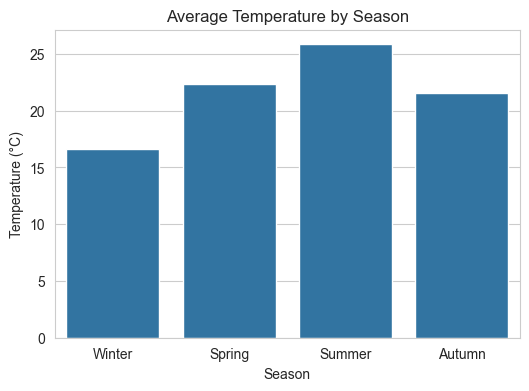

In [12]:
plt.figure(figsize=(6,4))
sns.barplot(
    x=seasonal_avg.index,
    y=seasonal_avg["temperature_celsius"]
)
plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

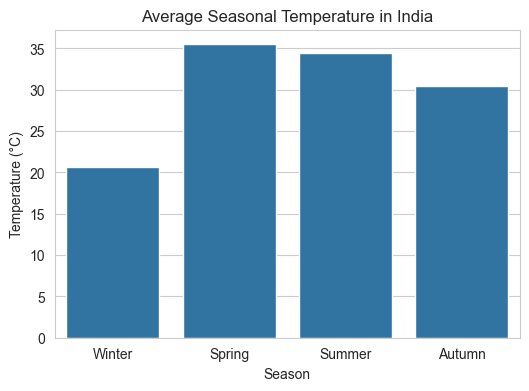

In [13]:
country_name = "India"

country_df = df[df["country"] == country_name]

seasonal_country = (
    country_df.groupby("season")["temperature_celsius"]
    .mean()
    .reindex(["Winter", "Spring", "Summer", "Autumn"])
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=seasonal_country,
    x="season",
    y="temperature_celsius"
)
plt.title(f"Average Seasonal Temperature in {country_name}")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.show()

C:\Users\keert\AppData\Local\Temp\ipykernel_192\1709270238.py:12: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


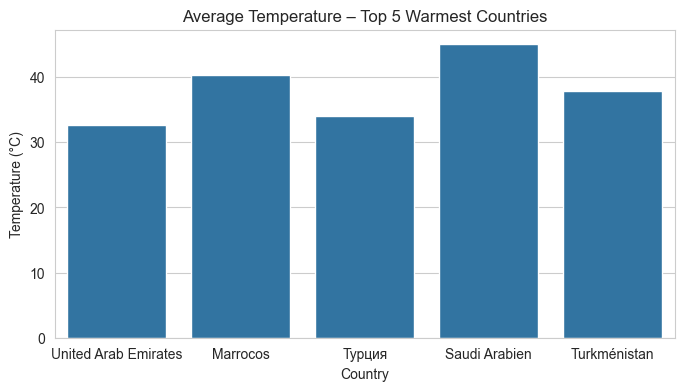

In [14]:
top_countries = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_df = df[df["country"].isin(top_countries)]

plt.figure(figsize=(8,4))
sns.barplot(
    data=top_df,
    x="country",
    y="temperature_celsius",
    ci=None
)
plt.title("Average Temperature – Top 5 Warmest Countries")
plt.xlabel("Country")
plt.ylabel("Temperature (°C)")
plt.show()

In [15]:
temp_threshold = df["temperature_celsius"].quantile(0.95)
precip_threshold = df["precip_mm"].quantile(0.95)

extreme_events = df[
    (df["temperature_celsius"] > temp_threshold) |
    (df["precip_mm"] > precip_threshold)
]

print("Extreme events count:", extreme_events.shape[0])

Extreme events count: 12438


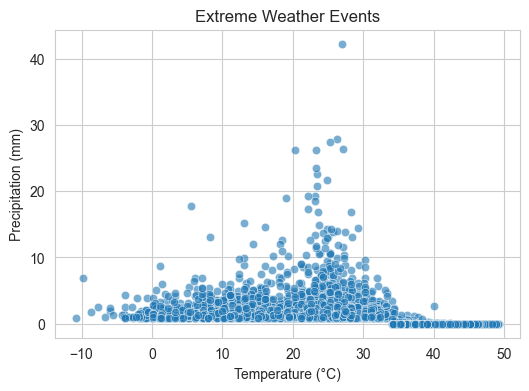

In [16]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=extreme_events["temperature_celsius"],
    y=extreme_events["precip_mm"],
    alpha=0.6
)
plt.title("Extreme Weather Events")
plt.xlabel("Temperature (°C)")
plt.ylabel("Precipitation (mm)")
plt.show()

C:\Users\keert\AppData\Local\Temp\ipykernel_192\3721939284.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


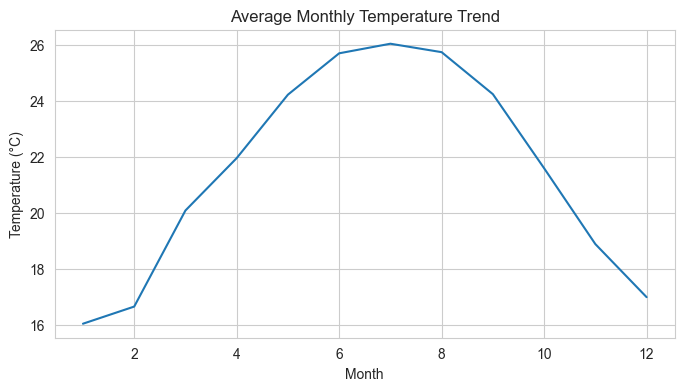

In [17]:
monthly_temp = (
    df.groupby(["year", "month"])["temperature_celsius"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
sns.lineplot(
    data=monthly_temp,
    x="month",
    y="temperature_celsius",
    ci=None
)
plt.title("Average Monthly Temperature Trend")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.show()